In [6]:


# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
import warnings
warnings.filterwarnings("ignore")

# Load Dataset

df = pd.read_csv("car_data.csv")
data1 = pd.DataFrame(df)

print(df.head())

print(df.shape)

print(df.columns)

print(df.info())

print(df.isnull().sum())

print(df.describe())


print("\nDuplicate Rows :", df.duplicated().sum())

# Remove duplicates if any
df.drop_duplicates(inplace=True)


current_year = 2025
df["Car_Age"] = current_year - df["Year"]

df.drop(["Car_Name", "Year"], axis=1, inplace=True)

print("\nUpdated Dataset")
print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0    Amaze  2013           0.80           7.69       41048    Petrol   
1   Innova  2018           7.61          19.94       17280    Petrol   
2   Ertiga  2018           1.66          10.38       82236    Petrol   
3      i20  2014           0.80           7.54      105072    Petrol   
4    Venue  2012           0.80          12.55       75284    Petrol   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      1  
1      Dealer       Manual      0  
2  Individual    Automatic      0  
3      Dealer       Manual      1  
4  Individual       Manual      0  
(300, 9)
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  

In [7]:
data1.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,Amaze,2013,0.80,7.69,41048,Petrol,Dealer,Manual,1
1,Innova,2018,7.61,19.94,17280,Petrol,Dealer,Manual,0
2,Ertiga,2018,1.66,10.38,82236,Petrol,Individual,Automatic,0
3,i20,2014,0.80,7.54,105072,Petrol,Dealer,Manual,1
4,Venue,2012,0.80,12.55,75284,Petrol,Individual,Manual,0



Dataset after preprocessing
   Selling_Price  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  \
0           0.80           7.69       41048          1            0   
1           7.61          19.94       17280          1            0   
2           1.66          10.38       82236          1            1   
3           0.80           7.54      105072          1            0   
4           0.80          12.55       75284          1            1   

   Transmission  Owner  Car_Age  
0             1      1       12  
1             1      0        7  
2             0      0        7  
3             1      1       11  
4             1      0       13  

Data Types
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type          int64
Seller_Type        int64
Transmission       int64
Owner              int64
Car_Age            int64
dtype: object


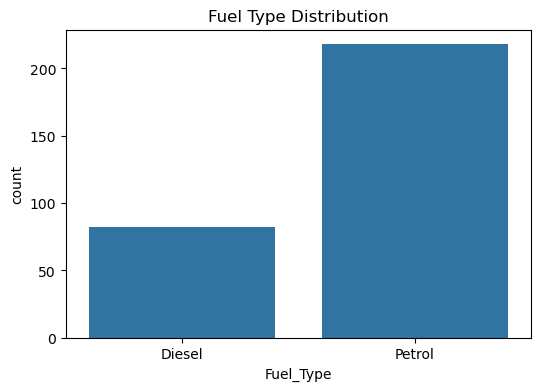

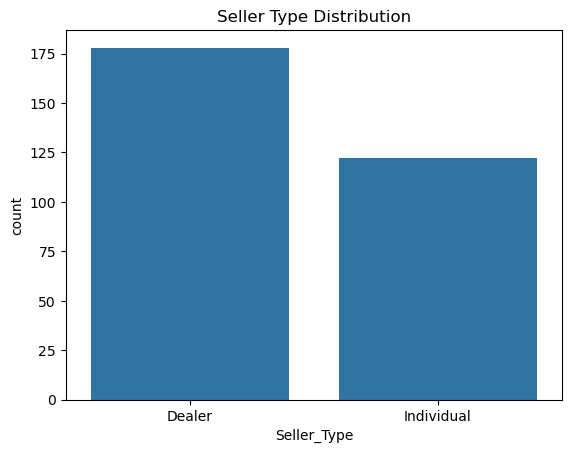

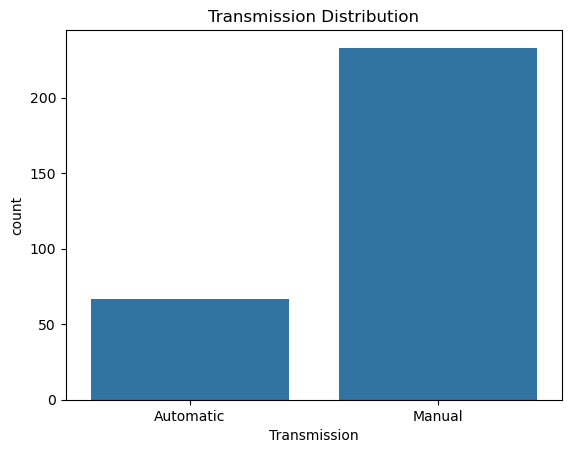

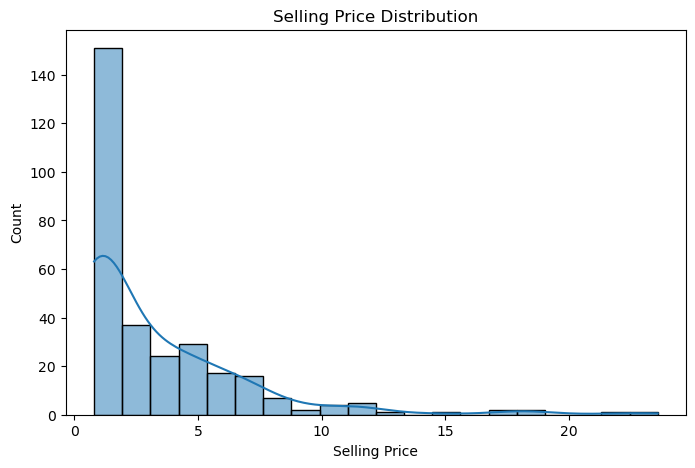

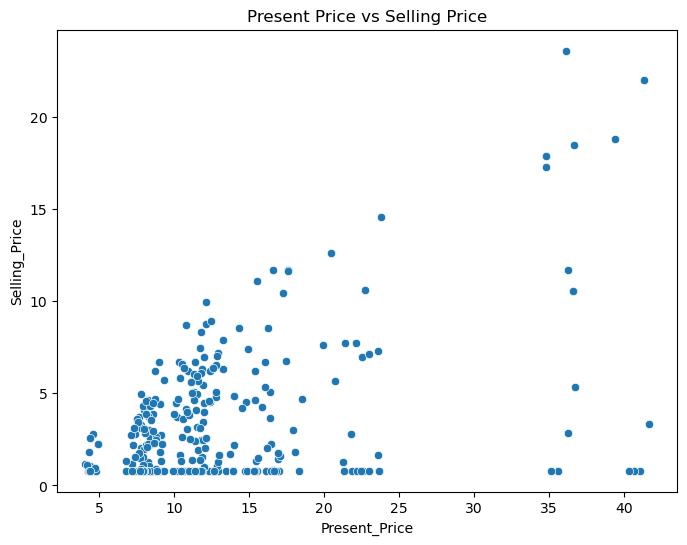

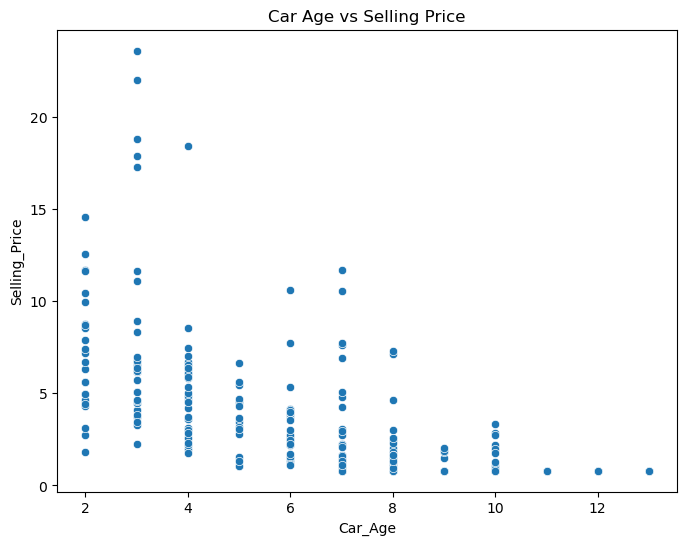


Dataset After Encoding
   Selling_Price  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  \
0           0.80           7.69       41048          1            0   
1           7.61          19.94       17280          1            0   
2           1.66          10.38       82236          1            1   
3           0.80           7.54      105072          1            0   
4           0.80          12.55       75284          1            1   

   Transmission  Owner  Car_Age  
0             1      1       12  
1             1      0        7  
2             0      0        7  
3             1      1       11  
4             1      0       13  


In [11]:

# Exploratory Data Analysis (EDA)

print("\nDataset after preprocessing")
print(df.head())

# Check data types
print("\nData Types")
print(df.dtypes)

# Count Plot - Fuel Type
plt.figure(figsize=(6,4))
sns.countplot(x='Fuel_Type', data=df)
plt.title("Fuel Type Distribution")
plt.xticks(ticks=[0, 1], labels=['Diesel', 'Petrol'])
plt.show()


# Count Plot - Seller Type

sns.countplot(x='Seller_Type', data=df)
plt.title("Seller Type Distribution")
plt.xticks(ticks=[0, 1], labels=['Dealer', 'Individual'])
plt.show()


# Count Plot - Transmission

sns.countplot(x='Transmission', data=df)
plt.title("Transmission Distribution")
plt.xticks(ticks=[0, 1], labels=['Automatic', 'Manual'])
plt.show()


# Selling Price Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Selling_Price"], bins=20, kde=True)
plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.show()


# Present Price vs Selling Price

plt.figure(figsize=(8,6))
sns.scatterplot(x="Present_Price",
                y="Selling_Price",
                data=df)

plt.title("Present Price vs Selling Price")
plt.show()


# Car Age vs Selling Price

plt.figure(figsize=(8,6))
sns.scatterplot(x="Car_Age",
                y="Selling_Price",
                data=df)

plt.title("Car Age vs Selling Price")
plt.show()

# Encode Categorical Variables


encoder = LabelEncoder()

df["Fuel_Type"] = encoder.fit_transform(df["Fuel_Type"])

df["Seller_Type"] = encoder.fit_transform(df["Seller_Type"])

df["Transmission"] = encoder.fit_transform(df["Transmission"])

print("\nDataset After Encoding")
print(df.head())



In [12]:
# Model Training

# Features (X) and Target (y)
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

#Linear Regression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_prediction = lr.predict(X_test)

print("\nLinear Regression")

print("R2 Score :", r2_score(y_test, lr_prediction))
print("MAE :", mean_absolute_error(y_test, lr_prediction))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_prediction)))

#Decision Tree

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_prediction = dt.predict(X_test)

print("\nDecision Tree")

print("R2 Score :", r2_score(y_test, dt_prediction))
print("MAE :", mean_absolute_error(y_test, dt_prediction))
print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_prediction)))

#Random Forest

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_prediction = rf.predict(X_test)

print("\nRandom Forest")

print("R2 Score :", r2_score(y_test, rf_prediction))
print("MAE :", mean_absolute_error(y_test, rf_prediction))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_prediction)))

#Compare Model Accuracy

models = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "R2 Score": [

        r2_score(y_test, lr_prediction),
        r2_score(y_test, dt_prediction),
        r2_score(y_test, rf_prediction)

    ]

})

print("\n")
print("Model Comparison")

print(models)
# Best Model

best_model = models.loc[models["R2 Score"].idxmax()]

print("\nBest Model is :", best_model["Model"])
print("Accuracy :", best_model["R2 Score"])


Training Samples : (240, 7)
Testing Samples : (60, 7)

Linear Regression
R2 Score : 0.747108776247414
MAE : 1.18188295518799
RMSE : 1.698028193306099

Decision Tree
R2 Score : 0.8529231828770006
MAE : 0.6543333333333333
RMSE : 1.2949414401174029

Random Forest
R2 Score : 0.8649514550564511
MAE : 0.5916383333333332
RMSE : 1.2408605356095954


Model Comparison
               Model  R2 Score
0  Linear Regression  0.747109
1      Decision Tree  0.852923
2      Random Forest  0.864951

Best Model is : Random Forest
Accuracy : 0.8649514550564511


In [14]:

# Save Random Forest Model (assuming it performed best)
joblib.dump(rf, "car_price_model.pkl")

print("\nModel saved successfully as 'car_price_model.pkl'")



print("\nCar Price Prediction")

present_price = float(input("Enter Present Price (in lakhs): "))
kms_driven = int(input("Enter Kilometers Driven: "))
fuel_type = input("Enter Fuel Type (Petrol/Diesel/CNG): ")
seller_type = input("Enter Seller Type (Dealer/Individual): ")
transmission = input("Enter Transmission (Manual/Automatic): ")
owner = int(input("Enter Number of Previous Owners (0/1/2/3): "))
car_age = int(input("Enter Car Age (Years): "))

# Encode user inputs
fuel_dict = {
    "Petrol": 2,
    "Diesel": 1,
    "CNG": 0
}

seller_dict = {
    "Dealer": 0,
    "Individual": 1
}

transmission_dict = {
    "Manual": 1,
    "Automatic": 0
}

fuel = fuel_dict.get(fuel_type, 2)
seller = seller_dict.get(seller_type, 0)
transmission = transmission_dict.get(transmission, 1)

# Prepare input data
new_car = pd.DataFrame([[
    present_price,
    kms_driven,
    fuel,
    seller,
    transmission,
    owner,
    car_age
]], columns=X.columns)

# Predict
predicted_price = rf.predict(new_car)

print("\n")
print(f"Estimated Selling Price: ₹ {predicted_price[0]:.2f} Lakhs")


Model saved successfully as 'car_price_model.pkl'

Car Price Prediction


Enter Present Price (in lakhs):  5
Enter Kilometers Driven:  25000
Enter Fuel Type (Petrol/Diesel/CNG):  Petrol
Enter Seller Type (Dealer/Individual):  Individual
Enter Transmission (Manual/Automatic):  Manual
Enter Number of Previous Owners (0/1/2/3):  1
Enter Car Age (Years):  4




Estimated Selling Price: ₹ 3.51 Lakhs
